# Vector Quantization Variational Convolutional Auto Encoder

In [37]:
import cv2
import os
import pandas as pd
import numpy as np
import torch
from torch import nn as nn
from torch import optim as optim
from torch.nn import functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
from PIL import Image
from matplotlib import pyplot as plt
from transformers import get_cosine_schedule_with_warmup

from FHFData import Kantec2509Dataset

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        
        if out_channels > 1: # Only apply if there is more than one channel
            self.norm = nn.InstanceNorm2d(out_channels, affine=True) 
        else:
            self.norm = nn.Identity() 

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x).contiguous()
        return self.relu(self.norm(x))

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.norm1 = nn.InstanceNorm2d(channels, affine=True)
        
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0)
        self.norm2 = nn.InstanceNorm2d(channels, affine=True)

    def forward(self, x):
        # Path 1
        y = self.conv1(x).contiguous() 
        y = F.relu(self.norm1(y))

        # Path 2
        y = self.conv2(y).contiguous()
        y = self.norm2(y)

        # Skip connection
        return F.relu(x + y)

In [5]:
class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1):
        super().__init__()
        self.trans_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        
        if out_channels > 1:
            self.norm = nn.InstanceNorm2d(out_channels, affine=True)
        else:
            self.norm = nn.Identity() 

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.trans_conv(x).contiguous() # Ensure contiguity after transpose conv
        return self.relu(self.norm(x))

In [6]:
class VectorQuantization(nn.Module):
    """
    The Vector Quantization layer.
    Quantizes the input feature map (B, C, H, W) to the nearest codebook vector.
    """
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings # K: Size of the codebook
        self.embedding_dim = embedding_dim   # D: Dimension of each vector
        self.commitment_cost = commitment_cost

        # Define the codebook (the embedding matrix)
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        # Initialize the codebook weights uniformly
        self.embedding.weight.data.uniform_(-1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, z):
        # 1. Reshape Input: (B, C, H, W) -> (B*H*W, C)
        flat_input = z.permute(0, 2, 3, 1).contiguous() # (B, H, W, C)
        flat_input = flat_input.view(-1, self.embedding_dim) # (N, D) where N=B*H*W

        # 2. Compute Distances: ||z - e_i||^2
        # (N, D) - (K, D) -> (N, K) distance matrix
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True)
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(flat_input, self.embedding.weight.t()))

        # 3. Find Nearest Codebook Vector (Min Distance Index)
        # min_encoding_indices is (N,) containing indices 0 to K-1
        min_encoding_indices = torch.argmin(distances, dim=1)
        
        # 4. Quantize: Look up the codebook vector for each index
        # quantized is (N, D)
        quantized = self.embedding(min_encoding_indices).view(z.shape[0], z.shape[2], z.shape[3], -1)
        quantized = quantized.permute(0, 3, 1, 2).contiguous() # (B, C, H, W)

        # 5. Straight-Through Estimator (STE)
        # Gradients of the embedding e_i are copied to the input z_e (encoder output)
        quantized_st = z + (quantized - z).detach()
        
        # 6. Calculate VQ Loss
        # VQ Loss = Codebook loss + Commitment loss
        # Codebook loss (e_i moves towards z_e): ||sg[z_e] - e||^2
        codebook_loss = F.mse_loss(quantized, z.detach())
        # Commitment loss (z_e commits to e_i): ||z_e - sg[e]||^2
        commitment_loss = F.mse_loss(z, quantized.detach()) * self.commitment_cost
        
        vq_loss = codebook_loss + commitment_loss
        
        return quantized_st, vq_loss, min_encoding_indices

In [7]:
class VQVCAE(nn.Module):
    """
    The full VQVCAE with correct channel mapping using a projection layer.
    """
    def __init__(self, input_channels, num_hiddens, num_residual_layers, num_embeddings, embedding_dim):
        super().__init__()
        
        # --- Encoder (Channel increase and downsampling) ---
        
        # Initial Conv (3 -> num_hiddens // 2)
        self.first_conv = nn.Sequential(
            nn.Conv2d(input_channels, num_hiddens // 2, kernel_size=4, stride=2, padding=1),
            nn.Identity(), 
            nn.ReLU(inplace=True)
        )
        
        # Body (num_hiddens // 2 -> num_hiddens, including ResBlocks)
        encoder_body_layers = [
            ConvBlock(num_hiddens // 2, num_hiddens, kernel_size=4, stride=2, padding=1),
            nn.Conv2d(num_hiddens, num_hiddens, kernel_size=3, stride=1, padding=1)
        ]
        for _ in range(num_residual_layers):
            encoder_body_layers.append(ResidualBlock(num_hiddens))
            
        self.encoder_body = nn.Sequential(*encoder_body_layers)

        # --- FIX: PROJECTION LAYER ---
        # Map num_hiddens (128) to embedding_dim (64) before VQ
        self.pre_quantization_conv = nn.Conv2d(num_hiddens, embedding_dim, kernel_size=1)
        
        # --- Vector Quantization Layer ---
        # This layer now receives embedding_dim (64) channels.
        self.vq_layer = VectorQuantization(num_embeddings, embedding_dim)
        
        # --- Decoder (Upsampling and reconstruction) ---
        
        decoder_layers = []
        
        # 1. Initial Decoder Conv: Receives embedding_dim (64) and projects back to num_hiddens (128)
        decoder_layers.append(nn.Conv2d(embedding_dim, num_hiddens, kernel_size=3, stride=1, padding=1))
        
        # 2. Residual Blocks
        for _ in range(num_residual_layers):
            decoder_layers.append(ResidualBlock(num_hiddens))
            
        # 3. Upsampling Transpose Conv layers
        decoder_layers.append(TransposeConvBlock(num_hiddens, num_hiddens // 2, kernel_size=4, stride=2, padding=1))
        decoder_layers.append(TransposeConvBlock(num_hiddens // 2, input_channels, kernel_size=4, stride=2, padding=1))
        
        # 4. Final output layer
        decoder_layers.append(nn.Conv2d(input_channels, input_channels, kernel_size=1)) 
        self.decoder = nn.Sequential(*decoder_layers)


    def forward(self, x):
        # 1. Encode
        z_e = self.first_conv(x)
        z_e = self.encoder_body(z_e)
        
        # 2. Project latent space channels to embedding dimension
        z_proj = self.pre_quantization_conv(z_e)
        
        # 3. Quantize (Input and Output now have embedding_dim channels)
        quantized_st, vq_loss, indices = self.vq_layer(z_proj)
        
        # 4. Decode (Receives quantized_st with embedding_dim channels)
        x_recon = self.decoder(quantized_st)
        
        return x_recon, vq_loss, indices

In [29]:
# Model Hyperparameters
input_channels = 1 # RGB images
num_hiddens = 128 # Feature map size (D) - Divisible by 8 (NUM_GROUPS)
num_residual_layers = 2
num_embeddings = 512
embedding_dim = 64 # Dimension of codebook vectors
batch_size = 128
height = 256
width = 256

# Create model instance
model = VQVCAE(input_channels, num_hiddens, num_residual_layers, num_embeddings, embedding_dim)

# Dummy Input
dummy_input = torch.randn(batch_size, input_channels, height, width)

# Run forward pass (This will now run without GroupNorm errors)
output, vq_loss, indices = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Reconstructed shape: {output.shape}")
print(f"VQ Loss: {vq_loss.item():.4f}")

Input shape: torch.Size([128, 1, 256, 256])
Reconstructed shape: torch.Size([128, 1, 256, 256])
VQ Loss: 0.5756


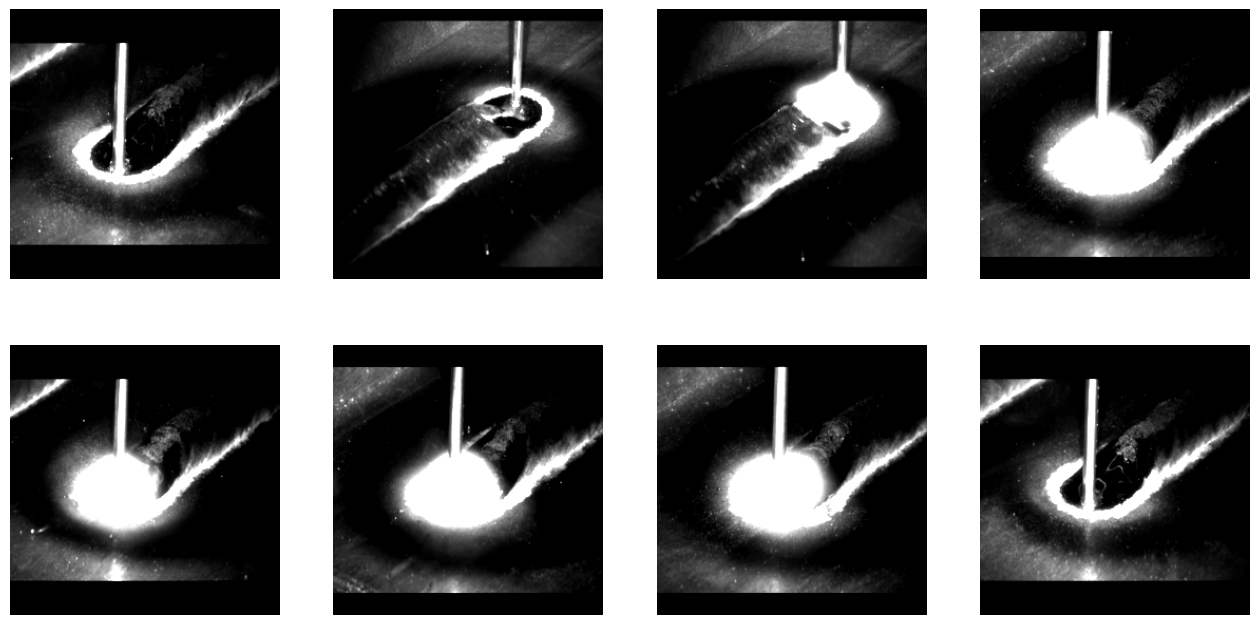

In [30]:
transform = v2.Compose([
    v2.Resize((height, width)),
    v2.Grayscale(num_output_channels=1),
    v2.ColorJitter(contrast=(2.0, 2.0)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

dataset = Kantec2509Dataset(transform=transform)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch = next(iter(train_dataloader))
images = batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, img in enumerate(images[:8]):
    axes[i].imshow(img.permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.train()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, amsgrad=False)
reconstruction_criterion = nn.MSELoss()

In [17]:
def save_checkpoint(model, optimizer, epoch, total_loss, filename="vqvcae_checkpoint.pth"):
    """Saves the current training state."""
    
    # Optional: Create the directory if it doesn't exist
    # os.makedirs("checkpoints", exist_ok=True) 
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': total_loss,
    }
    # Save the dictionary to a file
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved to {filename} at Epoch {epoch+1}")

In [18]:
def load_checkpoint(model, optimizer, filename="vqvcae_best_model.pth", device='cpu'):
    """Loads a saved checkpoint and returns the starting epoch."""
    
    if not os.path.exists(filename):
        print(f"Checkpoint file {filename} not found. Starting training from epoch 0.")
        return 0
    
    # Load the checkpoint dictionary, mapping tensors to the correct device
    checkpoint = torch.load(filename, map_location=device)
    
    # Load the state dictionaries
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Determine the starting epoch
    start_epoch = checkpoint['epoch'] + 1
    
    print(f"Checkpoint loaded successfully. Resuming training from Epoch {start_epoch}.")
    
    return start_epoch

In [19]:
def validate_epoch(model, val_dataloader, criterion, device):
    """Calculates the average total loss on the validation set."""
    
    model.eval() # Set model to evaluation mode (crucial!)
    total_val_loss = 0.0
    num_batches = 0
    
    # Disable gradient calculations during validation
    with torch.no_grad():
        for data in val_dataloader:
            data = data.to(device)
            
            x_recon, vq_loss, _ = model(data)
            
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            total_val_loss += total_loss.item()
            num_batches += 1
            
    # Calculate average loss over the validation set
    avg_val_loss = total_val_loss / num_batches
    print(f'\n--- Validation Complete --- Avg. Validation Loss: {avg_val_loss:.4f}')
    
    return avg_val_loss

In [21]:
def train_vqvae_final(model, train_dataloader, val_dataloader, optimizer, num_epochs, criterion, device, start_epoch=0, checkpoint_path="vqvcae_best_model.pth"):
    
    print(f"Starting VQVCAE Training on device: {device}")
    
    # Initialize best_val_loss from a very high number
    best_val_loss = float('inf') 
    
    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train() # Set to training mode at the start of the epoch
        avg_train_loss = 0.0
        
        for i, data in enumerate(train_dataloader): 
            
            # Training steps (Forward/Backward Pass)
            data = data.to(device)
            x_recon, vq_loss, _ = model(data)
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            avg_train_loss += total_loss.item()
            
            # --- Logging ---
            if (i + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{start_epoch + num_epochs}], '
                      f'Step [{i+1}/{len(train_dataloader)}], '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'Recon Loss: {recon_loss.item():.4f}, '
                      f'VQ Loss: {vq_loss.item():.4f}')
                
        # -------------------------------------------------------------
        # End of Epoch: Run Validation
        # -------------------------------------------------------------
        current_val_loss = validate_epoch(model, val_dataloader, criterion, device)
        
        # Save Checkpoint Logic: Save only if validation loss improves
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            # Call your separate save_checkpoint function
            save_checkpoint(model, optimizer, epoch, current_val_loss, checkpoint_path)
            print(f"Saved Best Model with Val Loss: {best_val_loss:.4f}")
            
    print("Training finished.")

In [22]:
def test_model(model, test_dataloader, criterion, device, checkpoint_path="vqvcae_best_model.pth"):
    """
    Loads the best saved model and evaluates performance on the test set.
    """
    # Load the best model weights first (optional, but highly recommended)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model saved at epoch {checkpoint['epoch']+1}.")
    except Exception as e:
        print(f"Warning: Could not load checkpoint from {checkpoint_path}. Testing current model state.")
    
    model.eval() # Set to evaluation mode
    total_test_loss = 0.0
    num_batches = 0
    
    # Store individual image errors or latent codes if you plan to do anomaly detection
    # all_anomaly_scores = []
    
    with torch.no_grad():
        for data in test_dataloader:
            data = data.to(device)
            
            x_recon, vq_loss, _ = model(data)
            
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            total_test_loss += total_loss.item()
            num_batches += 1
            
            # Example: Calculate anomaly scores here if desired (see previous step)
            # anomaly_scores = torch.sum(torch.square(x_recon - data), dim=[1, 2, 3]).cpu().numpy()
            # all_anomaly_scores.extend(anomaly_scores)

    avg_test_loss = total_test_loss / num_batches
    print(f'\n==================================================')
    print(f'FINAL TEST RESULT: Avg. Test Loss: {avg_test_loss:.4f}')
    print(f'==================================================')
    
    return avg_test_loss # , all_anomaly_scores

In [33]:
start_epoch, best_val_loss = 0, float('inf')

num_epochs = 100

CHECKPOINT_PATH = "vqvcae_karsten.pth"

# Load existing checkpoint if it exists
try:
    start_epoch = load_checkpoint(model, optimizer, CHECKPOINT_PATH, device)
except Exception as e:
    print(f"Error loading checkpoint: {e}. Starting fresh.")
    start_epoch, best_val_loss = 0, float('inf')


# --- 4. EXECUTION: Training and Validation ---
print("\n" + "="*50)
print("STARTING/RESUMING TRAINING")
print("="*50)

# Pass all necessary objects to the training function
train_vqvae_final(
    model=model, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader,
    optimizer=optimizer, 
    num_epochs=num_epochs, 
    criterion=reconstruction_criterion, 
    device=device, 
    start_epoch=start_epoch,
    checkpoint_path=CHECKPOINT_PATH
)


# --- 5. EXECUTION: Final Testing ---
print("\n" + "="*50)
print("RUNNING FINAL TEST EVALUATION")
print("="*50)

# The test function will load the best model saved during training
final_test_loss = test_model(
    model=model, 
    test_dataloader=test_dataloader, 
    criterion=reconstruction_criterion, 
    device=device,
    checkpoint_path=CHECKPOINT_PATH
)

Checkpoint file vqvcae_karsten.pth not found. Starting training from epoch 0.

STARTING/RESUMING TRAINING
Starting VQVCAE Training on device: cuda



KeyboardInterrupt



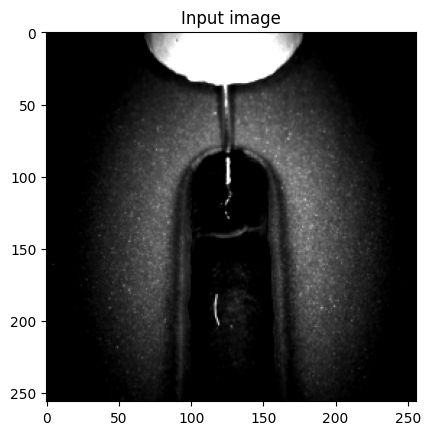

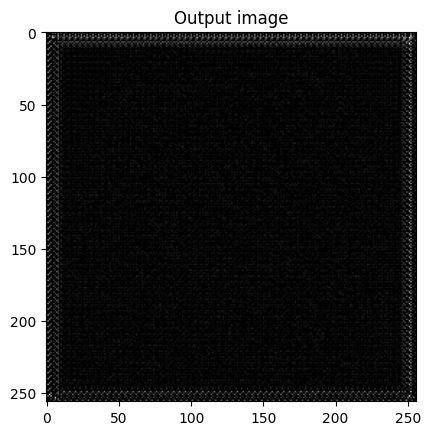

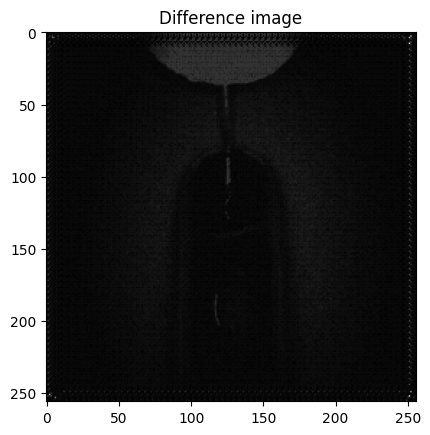

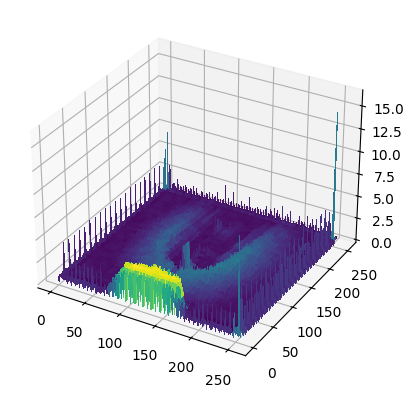

In [44]:
model.eval()
test_image_in = Image.open("test_anomaly.jpg")
test_image_in = transform(test_image_in)

test_tensor_in = test_image_in.unsqueeze(0) # Shape: [1, 1, width, height]
test_tensor_in = test_tensor_in.to(device)

with torch.no_grad():
    test_tensor_out, vq_loss, indices = model(test_tensor_in)
test_image_out = test_tensor_out.squeeze(0) # Shape: [1, 128, 128]
test_image_out = test_image_out.cpu()

test_image_diff = np.square(test_image_in.permute(1,2,0).numpy().squeeze() - test_image_out.permute(1,2,0).numpy().squeeze()) 

plt.title("Input image")
plt.imshow(test_image_in.permute(1, 2, 0).numpy().squeeze(), cmap="gray")
plt.show()
plt.title("Output image")
plt.imshow(test_image_out.permute(1, 2, 0).numpy().squeeze(), cmap="gray")
plt.show()
plt.title("Difference image")
plt.imshow(test_image_diff, cmap="gray")
plt.show()

xx, yy = np.meshgrid(np.arange(height), np.arange(width))
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(xx, yy, test_image_diff, cmap="viridis", linewidth=0, antialiased=False)
plt.show()